In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install imbalanced-learn scikit-learn tensorflow matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_curve, auc, confusion_matrix
from scipy.cluster.hierarchy import linkage, dendrogram
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE


In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/preprocessed_features.csv')
if "Sub_ID" in df.columns:
    df.drop(columns=["Sub_ID"], inplace=True)


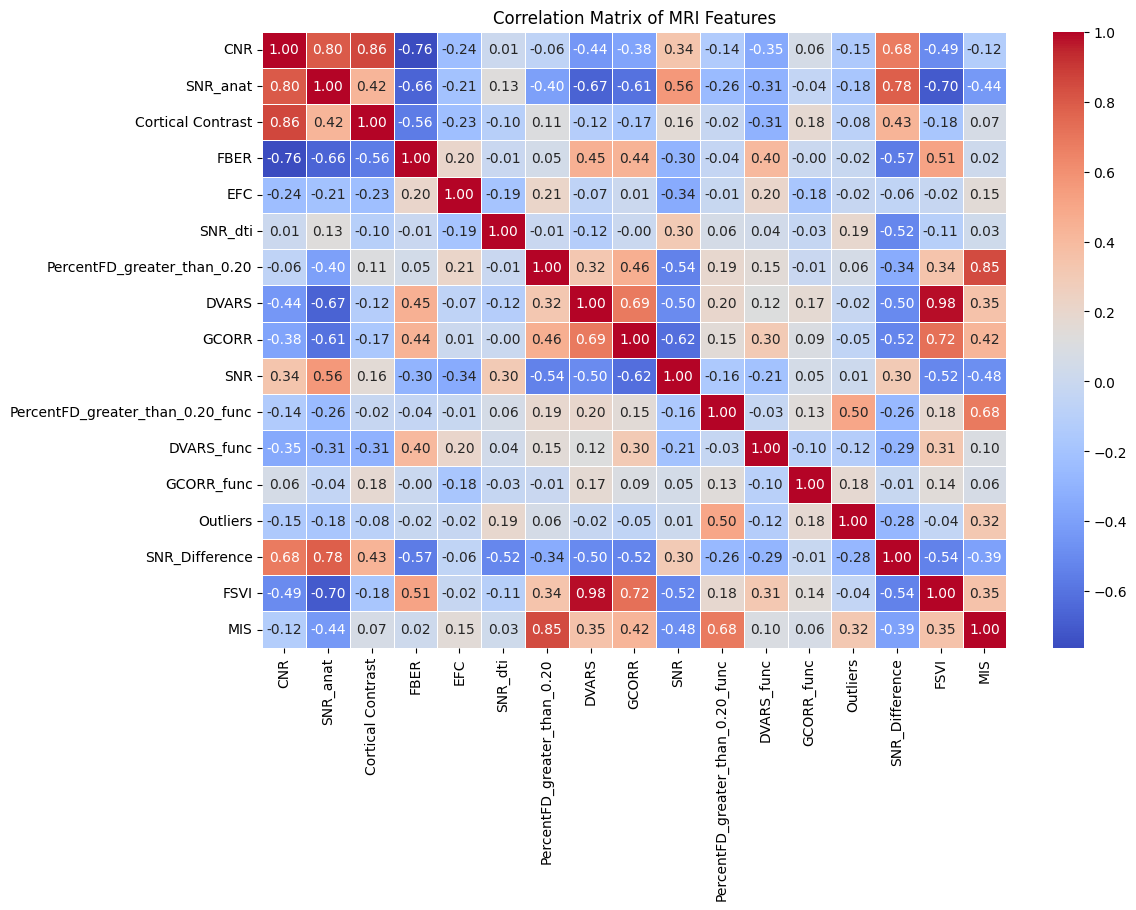

In [ ]:

# Compute new features
df["SNR_Difference"] = df["SNR_anat"] - df["SNR_dti"]
df["FSVI"] = df[["DVARS", "DVARS_func"]].mean(axis=1)
df["MIS"] = df[["PercentFD_greater_than_0.20", "PercentFD_greater_than_0.20_func"]].sum(axis=1)

df.fillna(df.median(), inplace=True)

# Correlation matrix
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of MRI Features")
plt.show()

features = numeric_df.columns.tolist()
X_features = df[features]

threshold = df["FSVI"].median()
df["Refined_Diagnosis"] = np.where(df["FSVI"] > threshold, "ASD-like", "Control-like")
y_labels = df["Refined_Diagnosis"].map({"Control-like": 0, "ASD-like": 1})

X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Random Forest Accuracy: 0.989247311827957
Random Forest Precision: 1.0
Random Forest Recall: 0.9782608695652174
Random Forest F1 Score: 0.989010989010989
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       1.00      0.98      0.99        46

    accuracy                           0.99        93
   macro avg       0.99      0.99      0.99        93
weighted avg       0.99      0.99      0.99        93



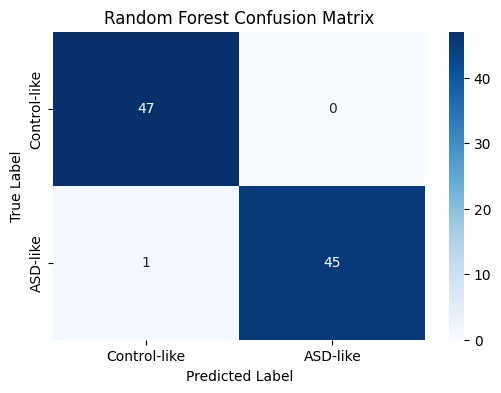

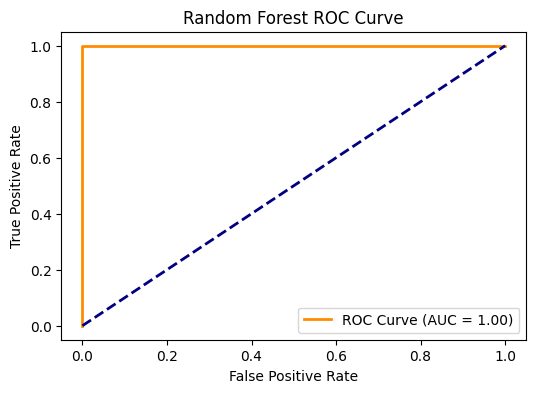

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest Precision:", precision_score(y_test, rf_pred))
print("Random Forest Recall:", recall_score(y_test, rf_pred))
print("Random Forest F1 Score:", f1_score(y_test, rf_pred))
print("Random Forest Classification Report:\n", classification_report(y_test, rf_pred))

# Confusion Matrix for Random Forest
conf_matrix_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=["Control-like", "ASD-like"], yticklabels=["Control-like", "ASD-like"])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve for Random Forest
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc_rf))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Random Forest ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

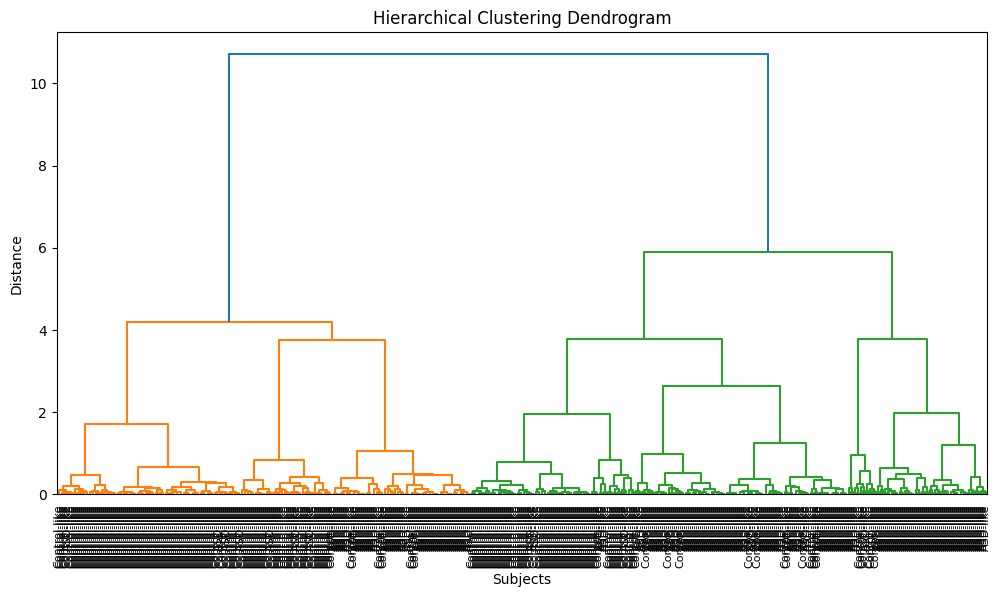

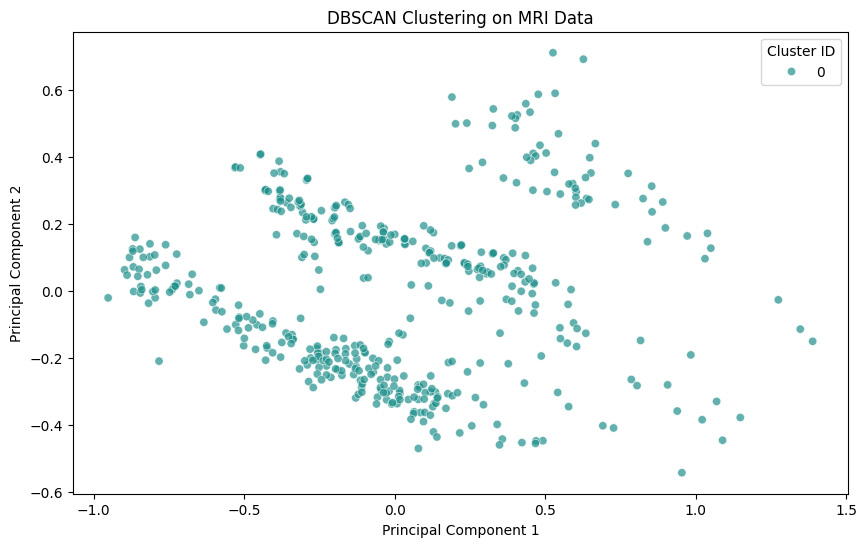

In [ ]:
# PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features)
df["PCA1"], df["PCA2"] = X_pca[:, 0], X_pca[:, 1]

# Hierarchical Clustering
plt.figure(figsize=(12, 6))
linkage_matrix = linkage(X_pca, method='ward')
dendrogram(linkage_matrix, labels=df["Refined_Diagnosis"].values, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Subjects")
plt.ylabel("Distance")
plt.show()

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_pca)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["PCA1"], y=df["PCA2"], hue=df["DBSCAN_Cluster"], palette="viridis", alpha=0.7)
plt.title("DBSCAN Clustering on MRI Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster ID")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.5388 - loss: 0.6830 - val_accuracy: 0.8649 - val_loss: 0.6570
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7353 - loss: 0.6472 - val_accuracy: 0.8649 - val_loss: 0.6125
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7763 - loss: 0.5932 - val_accuracy: 0.8108 - val_loss: 0.5490
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7961 - loss: 0.5240 - val_accuracy: 0.9189 - val_loss: 0.4666
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8593 - loss: 0.4489 - val_accuracy: 0.7973 - val_loss: 0.4214
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8078 - loss: 0.3898 - val_accuracy: 0.9054 - val_loss: 0.3558
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8700 - loss: 0.3667 - val_accuracy: 0.7973 - val_loss: 0.3584
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9015 - loss: 0.3228 - val_accuracy: 0.9459 - 

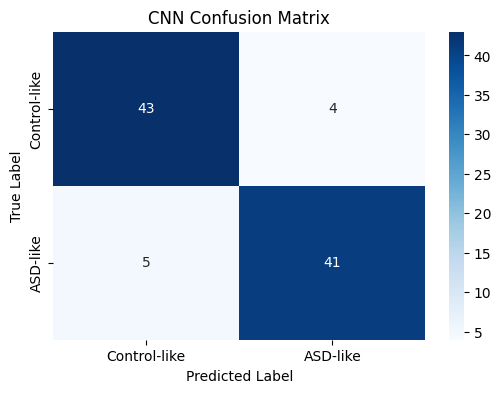

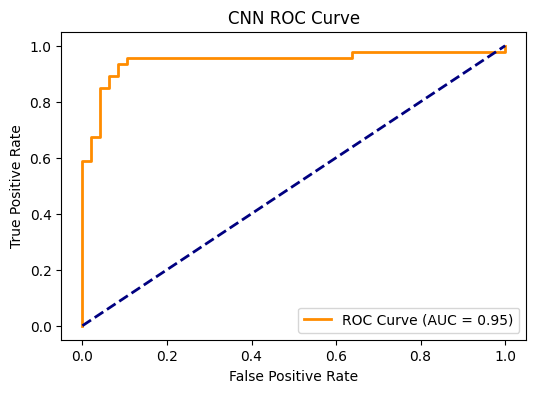

Top Outlier Deviations:
 CNR                           NaN
SNR_anat                      NaN
Cortical Contrast             NaN
FBER                          NaN
EFC                           NaN
SNR_dti                       NaN
PercentFD_greater_than_0.20   NaN
DVARS                         NaN
GCORR                         NaN
SNR                           NaN
dtype: float64


In [ ]:
# CNN Model
X_train_cnn_res = X_train_res.values.reshape(X_train_res.shape[0], X_train_res.shape[1], 1)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

y_train_cnn_res = to_categorical(y_train_res, num_classes=2)
y_test_cnn = to_categorical(y_test, num_classes=2)

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(2, activation='softmax'))

cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

history = cnn_model.fit(X_train_cnn_res, y_train_cnn_res, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# CNN Evaluation
cnn_pred_prob = cnn_model.predict(X_test_cnn)
cnn_pred = np.argmax(cnn_pred_prob, axis=1)
y_test_labels = np.argmax(y_test_cnn, axis=1)

print("CNN Accuracy:", accuracy_score(y_test_labels, cnn_pred))
print("CNN Precision:", precision_score(y_test_labels, cnn_pred))
print("CNN Recall:", recall_score(y_test_labels, cnn_pred))
print("CNN F1 Score:", f1_score(y_test_labels, cnn_pred))
print("CNN Classification Report:\n", classification_report(y_test_labels, cnn_pred))

# Confusion Matrix for CNN
conf_matrix_cnn = confusion_matrix(y_test_labels, cnn_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=["Control-like", "ASD-like"], yticklabels=["Control-like", "ASD-like"])
plt.title('CNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve for CNN
fpr_cnn, tpr_cnn, _ = roc_curve(y_test_labels, cnn_pred_prob[:, 1])
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

plt.figure(figsize=(6, 4))
plt.plot(fpr_cnn, tpr_cnn, color='darkorange', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc_cnn))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('CNN ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# Outlier Analysis
outliers_df = df[df["DBSCAN_Cluster"] == -1]
df = df[df["DBSCAN_Cluster"] != -1]
outlier_stats = outliers_df[features].mean()
non_outlier_stats = df[features].mean()
outlier_deviation = ((outlier_stats - non_outlier_stats) / non_outlier_stats) * 100
print("Top Outlier Deviations:\n", outlier_deviation.sort_values(ascending=False).head(10))


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.7922 - loss: 0.4682 - val_accuracy: 0.5135 - val_loss: 0.6907
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9166 - loss: 0.2036 - val_accuracy: 0.4865 - val_loss: 0.6884
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9594 - loss: 0.1102 - val_accuracy: 0.5135 - val_loss: 0.6738
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9561 - loss: 0.1168 - val_accuracy: 0.8108 - val_loss: 0.6717
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9900 - loss: 0.0495 - val_accuracy: 0.8108 - val_loss: 0.6543
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9269 - loss: 0.1336 - val_accuracy: 0.4865 - val_loss: 0.6993
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9670 - loss: 0.0774 - val_accuracy: 0.4865 - val_loss: 0.7519
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.9869 - loss: 0.0525 - val_accuracy: 0.4865 

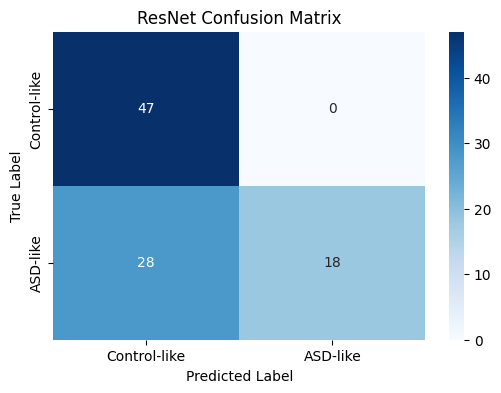

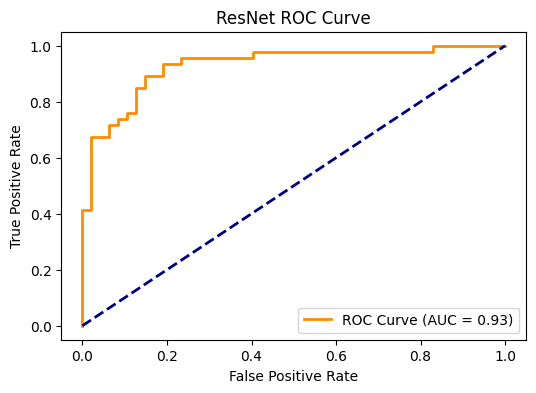

In [ ]:
#resnet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_curve, auc, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Activation, Add, GlobalAveragePooling1D, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/preprocessed_features.csv')

# Drop Sub_ID if present
if "Sub_ID" in df.columns:
    df.drop(columns=["Sub_ID"], inplace=True)

# Compute new features
df["SNR_Difference"] = df["SNR_anat"] - df["SNR_dti"]
df["FSVI"] = df[["DVARS", "DVARS_func"]].mean(axis=1)
df["MIS"] = df[["PercentFD_greater_than_0.20", "PercentFD_greater_than_0.20_func"]].sum(axis=1)

# Handle missing values
df.fillna(df.median(), inplace=True)

# Define features and target
numeric_df = df.select_dtypes(include=['number'])
features = numeric_df.columns.tolist()
X_features = df[features]

# Define binary target (ASD-like and Control-like)
threshold = df["FSVI"].median()
df["Refined_Diagnosis"] = np.where(df["FSVI"] > threshold, "ASD-like", "Control-like")
y_labels = df["Refined_Diagnosis"].map({"Control-like": 0, "ASD-like": 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

# Apply SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Reshape data for 1D ResNet (samples, time_steps, features)
X_train_res = X_train_res.values.reshape(X_train_res.shape[0], X_train_res.shape[1], 1)
X_test = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

# One-hot encode labels
y_train_res_cat = to_categorical(y_train_res, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Define a simple 1D ResNet block
def resnet_block(input_layer, filters, kernel_size=3):
    x = Conv1D(filters, kernel_size, padding="same")(input_layer)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv1D(filters, kernel_size, padding="same")(x)
    x = BatchNormalization()(x)

    # Skip connection
    shortcut = Conv1D(filters, 1, padding="same")(input_layer)
    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    return x

# Build the 1D ResNet model
input_layer = Input(shape=(X_train_res.shape[1], 1))
x = resnet_block(input_layer, 64)
x = resnet_block(x, 128)
x = resnet_block(x, 256)
x = GlobalAveragePooling1D()(x)
x = Dense(128, activation="relu")(x)
x = Dense(2, activation="softmax")(x)

resnet_model = Model(inputs=input_layer, outputs=x)

# Compile the model
resnet_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = resnet_model.fit(X_train_res, y_train_res_cat, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

# Predict on test set
y_pred_prob = resnet_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Evaluate performance
print("ResNet Accuracy:", accuracy_score(y_test, y_pred))
print("ResNet Precision:", precision_score(y_test, y_pred))
print("ResNet Recall:", recall_score(y_test, y_pred))
print("ResNet F1 Score:", f1_score(y_test, y_pred))
print("ResNet Classification Report:\n", classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["Control-like", "ASD-like"], yticklabels=["Control-like", "ASD-like"])
plt.title('ResNet Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ResNet ROC Curve')
plt.legend(loc="lower right")
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:50:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


SVM Accuracy: 0.967741935483871
SVM Precision: 0.9811320754716981
SVM Recall: 0.9629629629629629
SVM F1 Score: 0.9719626168224299
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        39
           1       0.98      0.96      0.97        54

    accuracy                           0.97        93
   macro avg       0.97      0.97      0.97        93
weighted avg       0.97      0.97      0.97        93

KNN Accuracy: 0.9247311827956989
KNN Precision: 0.9433962264150944
KNN Recall: 0.9259259259259259
KNN F1 Score: 0.9345794392523364
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91        39
           1       0.94      0.93      0.93        54

    accuracy                           0.92        93
   macro avg       0.92      0.92      0.92        93
weighted avg       0.93      0.92      0.92        93

XGBoost Accuracy: 1.0
XGBoost

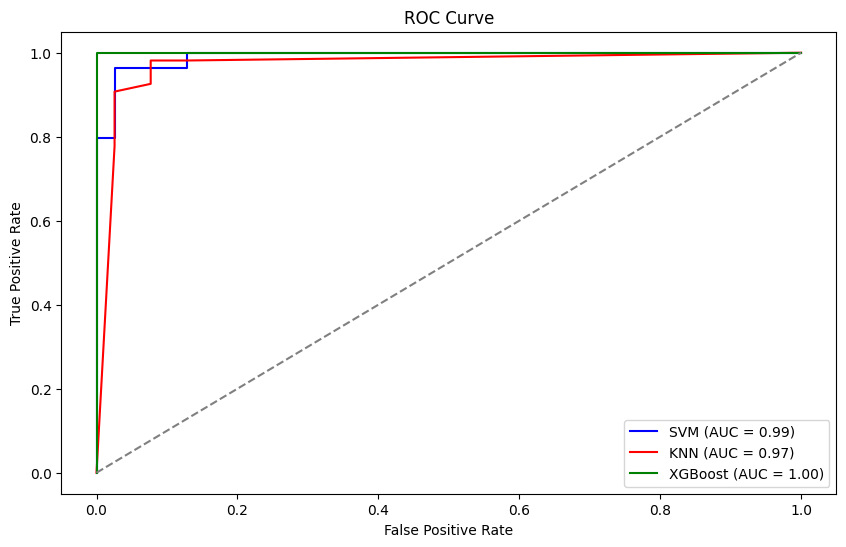

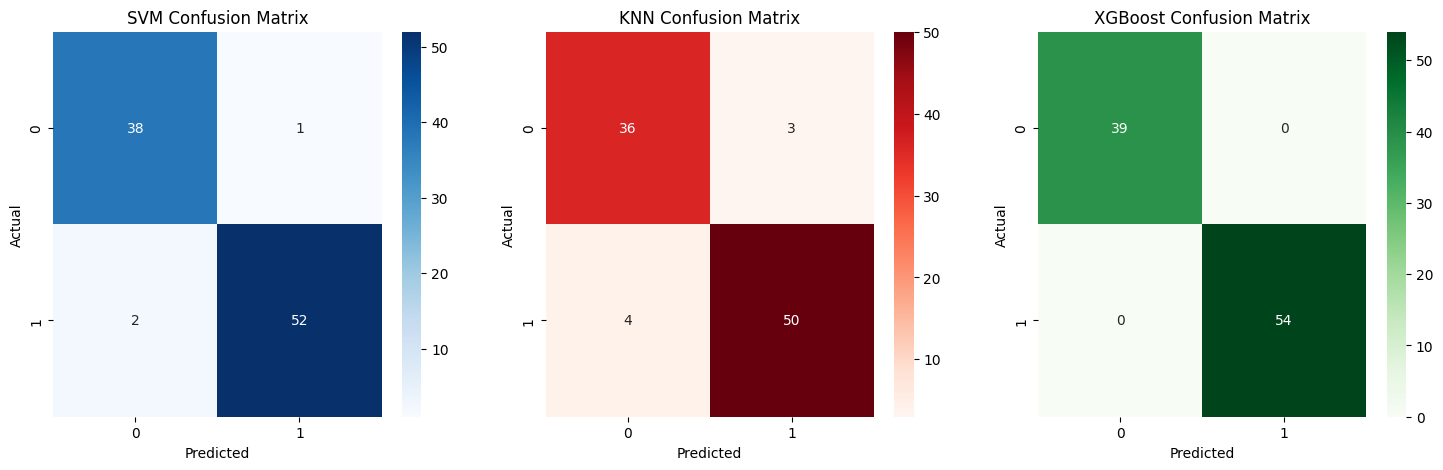

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_curve, auc, confusion_matrix
from scipy.cluster.hierarchy import linkage, dendrogram

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/preprocessed_features.csv')

# Ensure Sub_ID is removed if necessary
if "Sub_ID" in df.columns:
    df.drop(columns=["Sub_ID"], inplace=True)

# Compute new features
df["SNR_Difference"] = df["SNR_anat"] - df["SNR_dti"]
df["FSVI"] = df[["DVARS", "DVARS_func"]].mean(axis=1)
df["MIS"] = df[["PercentFD_greater_than_0.20", "PercentFD_greater_than_0.20_func"]].sum(axis=1)

# Handle missing values
df.fillna(df.median(), inplace=True)

# Define features for model training
numeric_df = df.select_dtypes(include=['number'])
features = numeric_df.columns.tolist()
X_features = df[features]

# Define target labels
threshold = df["FSVI"].median()
df["Refined_Diagnosis"] = np.where(df["FSVI"] > threshold, "ASD-like", "Control-like")
y_labels = df["Refined_Diagnosis"].map({"Control-like": 0, "ASD-like": 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=42)

# Train models
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42)
rf.fit(X_train, y_train)

param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1, 1], 'kernel': ['rbf']}
grid_search = GridSearchCV(SVC(probability=True), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
svm_model = grid_search.best_estimator_

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions
svm_pred, knn_pred, xgb_pred = svm_model.predict(X_test), knn_model.predict(X_test), xgb_model.predict(X_test)
svm_probs = svm_model.predict_proba(X_test)[:, 1]
knn_probs = knn_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Compute evaluation metrics
def evaluate_model(name, y_test, y_pred):
    print(f"{name} Accuracy:", accuracy_score(y_test, y_pred))
    print(f"{name} Precision:", precision_score(y_test, y_pred))
    print(f"{name} Recall:", recall_score(y_test, y_pred))
    print(f"{name} F1 Score:", f1_score(y_test, y_pred))
    print(f"{name} Classification Report:\n", classification_report(y_test, y_pred))

evaluate_model("SVM", y_test, svm_pred)
evaluate_model("KNN", y_test, knn_pred)
evaluate_model("XGBoost", y_test, xgb_pred)

# AUC-ROC Plots
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
roc_auc_svm = auc(fpr_svm, tpr_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_probs)
roc_auc_knn = auc(fpr_knn, tpr_knn)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(10, 6))
plt.plot(fpr_svm, tpr_svm, color='blue', label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot(fpr_knn, tpr_knn, color='red', label=f'KNN (AUC = {roc_auc_knn:.2f})')
plt.plot(fpr_xgb, tpr_xgb, color='green', label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Confusion Matrices
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 2)
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', cmap='Reds')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 3)
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

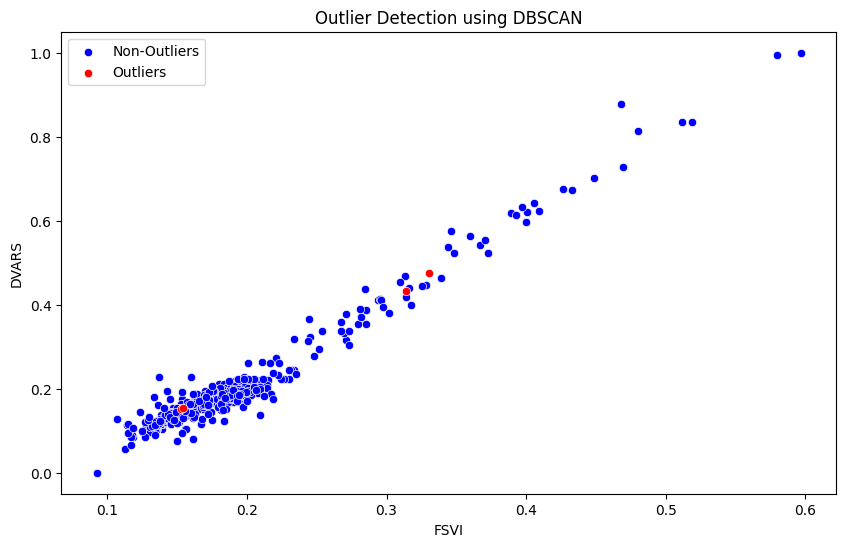

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:58:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Overall Model Evaluation:
Accuracy: 0.9565
Precision: 0.9594
Recall: 0.9592
F1 Score: 0.9592


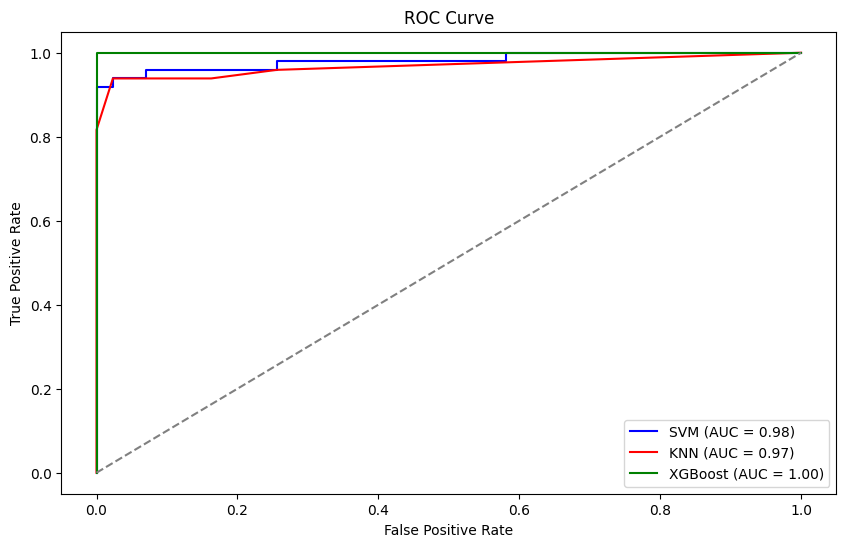

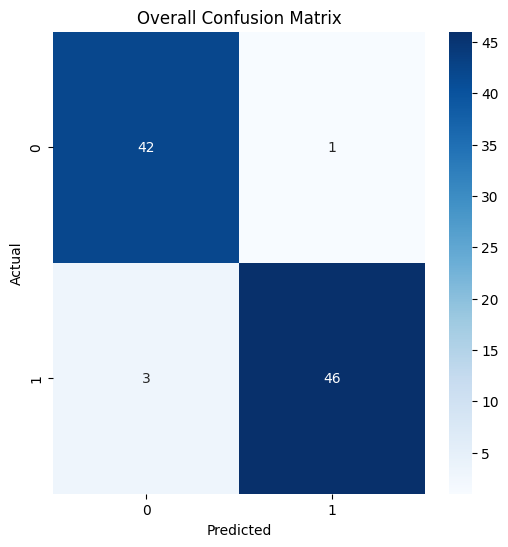

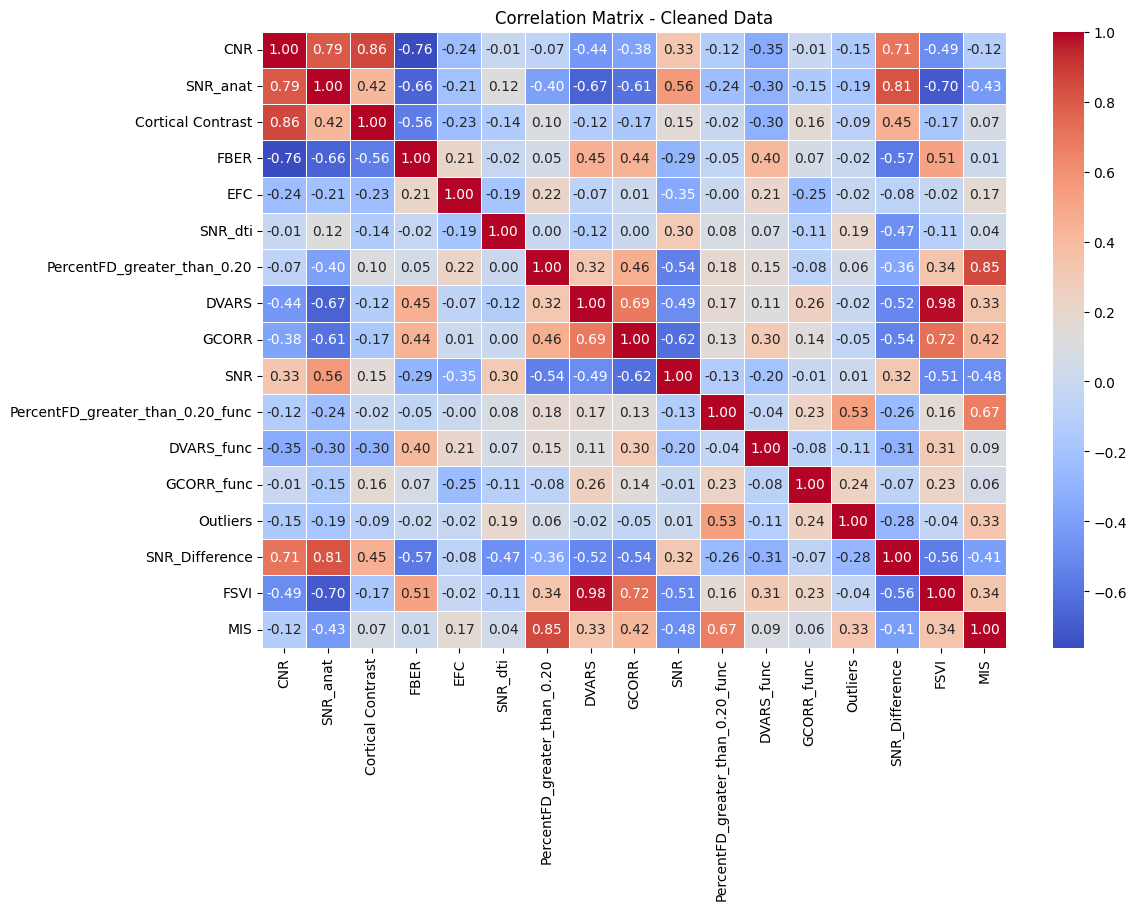

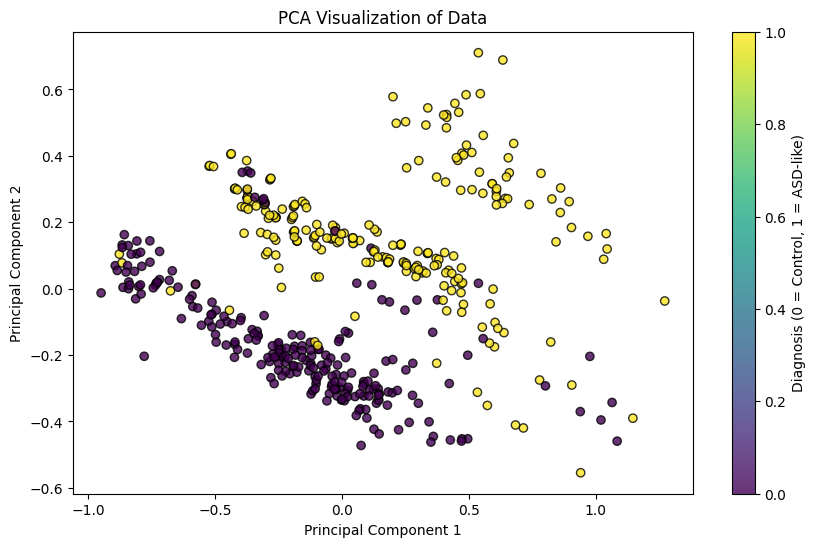

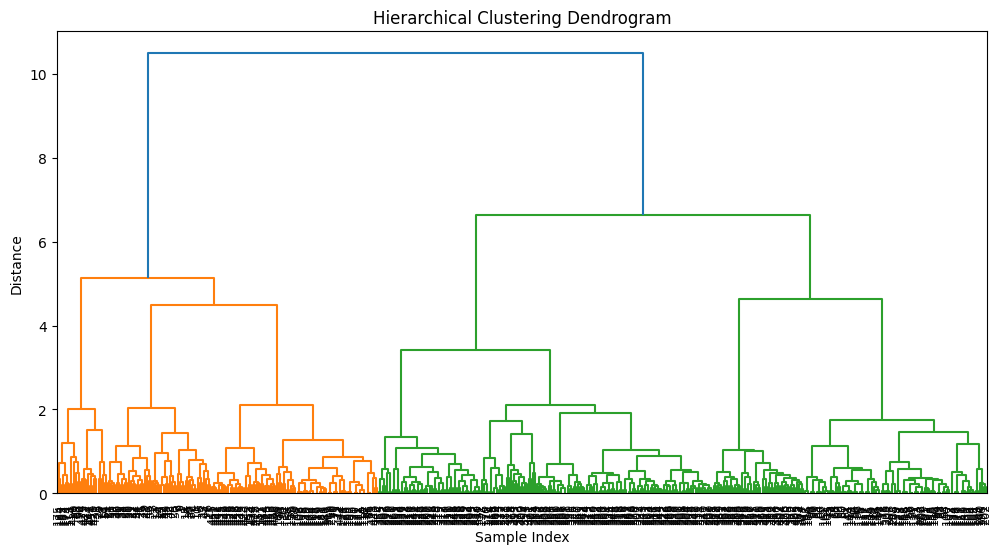

In [ ]:
#ENSEMBLE - MAJORITY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_curve, auc, confusion_matrix
from scipy.cluster.hierarchy import linkage, dendrogram

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/preprocessed_features.csv')


# Ensure Sub_ID is removed if necessary
if "Sub_ID" in df.columns:
    df.drop(columns=["Sub_ID"], inplace=True)

# Compute new features
df["SNR_Difference"] = df["SNR_anat"] - df["SNR_dti"]
df["FSVI"] = df[["DVARS", "DVARS_func"]].mean(axis=1)
df["MIS"] = df[["PercentFD_greater_than_0.20", "PercentFD_greater_than_0.20_func"]].sum(axis=1)

# Handle missing values
df.fillna(df.median(), inplace=True)

# Define features for model training
numeric_df = df.select_dtypes(include=['number'])
features = numeric_df.columns.tolist()
X_features = df[features]

# Define target labels
threshold = df["FSVI"].median()
df["Refined_Diagnosis"] = np.where(df["FSVI"] > threshold, "ASD-like", "Control-like")
y_labels = df["Refined_Diagnosis"].map({"Control-like": 0, "ASD-like": 1})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=42)

# Apply DBSCAN for outlier detection
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_features)

# Identify outliers (DBSCAN assigns label -1 to outliers)
outliers_df = df[df["DBSCAN_Cluster"] == -1]
non_outliers_df = df[df["DBSCAN_Cluster"] != -1]

# Visualize outliers
plt.figure(figsize=(10, 6))
sns.scatterplot(x=non_outliers_df['FSVI'], y=non_outliers_df['DVARS'], color='blue', label='Non-Outliers')
sns.scatterplot(x=outliers_df['FSVI'], y=outliers_df['DVARS'], color='red', label='Outliers')
plt.xlabel("FSVI")
plt.ylabel("DVARS")
plt.title("Outlier Detection using DBSCAN")
plt.legend()
plt.show()

# Optionally, remove outliers
df_cleaned = non_outliers_df.drop(columns=['DBSCAN_Cluster'])

# Define features for model training again (after removing outliers if necessary)
X_features_cleaned = df_cleaned[features]

# Re-split the cleaned data
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_features_cleaned, y_labels.loc[df_cleaned.index], test_size=0.2, random_state=42)

# Train models
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1, 1], 'kernel': ['rbf']}
grid_search = GridSearchCV(SVC(probability=True), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_cleaned, y_train_cleaned)
svm_model = grid_search.best_estimator_

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_cleaned, y_train_cleaned)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_cleaned, y_train_cleaned)

# Predictions
svm_pred, knn_pred, xgb_pred = svm_model.predict(X_test_cleaned), knn_model.predict(X_test_cleaned), xgb_model.predict(X_test_cleaned)
svm_probs = svm_model.predict_proba(X_test_cleaned)[:, 1]
knn_probs = knn_model.predict_proba(X_test_cleaned)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test_cleaned)[:, 1]

# Compute overall evaluation metrics
def evaluate_models(y_test, preds):
    overall_accuracy = np.mean([accuracy_score(y_test, pred) for pred in preds])
    overall_precision = np.mean([precision_score(y_test, pred) for pred in preds])
    overall_recall = np.mean([recall_score(y_test, pred) for pred in preds])
    overall_f1 = np.mean([f1_score(y_test, pred) for pred in preds])
    print("Overall Model Evaluation:")
    print(f"Accuracy: {overall_accuracy:.4f}")
    print(f"Precision: {overall_precision:.4f}")
    print(f"Recall: {overall_recall:.4f}")
    print(f"F1 Score: {overall_f1:.4f}")

evaluate_models(y_test_cleaned, [svm_pred, knn_pred, xgb_pred])

# AUC-ROC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test_cleaned, svm_probs)
fpr_knn, tpr_knn, _ = roc_curve(y_test_cleaned, knn_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_cleaned, xgb_probs)

plt.figure(figsize=(10, 6))
plt.plot(fpr_svm, tpr_svm, color='blue', label=f'SVM (AUC = {auc(fpr_svm, tpr_svm):.2f})')
plt.plot(fpr_knn, tpr_knn, color='red', label=f'KNN (AUC = {auc(fpr_knn, tpr_knn):.2f})')
plt.plot(fpr_xgb, tpr_xgb, color='green', label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Confusion Matrix for Combined Model Predictions
final_preds = (svm_pred + knn_pred + xgb_pred) >= 2  # Majority Voting
conf_matrix = confusion_matrix(y_test_cleaned, final_preds)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Overall Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df_cleaned.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix - Cleaned Data")
plt.show()

# PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features_cleaned)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_labels.loc[df_cleaned.index], cmap='viridis', edgecolor='k', alpha=0.8)
plt.colorbar(scatter, label="Diagnosis (0 = Control, 1 = ASD-like)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Data")
plt.show()

# Hierarchical Clustering Dendrogram
plt.figure(figsize=(12, 6))
linkage_matrix = linkage(X_features_cleaned, method='ward')
dendrogram(linkage_matrix, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.cluster import DBSCAN
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# 1. Load the Dataset
# Replace 'preprocessed_features.csv' with your actual file path
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/preprocessed_features.csv')

# 2. Preprocessing & Feature Engineering
if "Sub_ID" in df.columns:
    df.drop(columns=["Sub_ID"], inplace=True)

# Create engineered metrics
df["SNR_Difference"] = df["SNR_anat"] - df["SNR_dti"]
df["FSVI"] = df[["DVARS", "DVARS_func"]].mean(axis=1)
df["MIS"] = df[["PercentFD_greater_than_0.20", "PercentFD_greater_than_0.20_func"]].sum(axis=1)

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Select numeric features for the model
numeric_df = df.select_dtypes(include=['number'])
features = numeric_df.columns.tolist()
X_all = df[features]

# Define Target (Using the FSVI median threshold proxy)
threshold = df["FSVI"].median()
df["Target"] = np.where(df["FSVI"] > threshold, 1, 0)
y_all = df["Target"]

# 3. Outlier Removal (DBSCAN)
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_all)
df_cleaned = df[df["DBSCAN_Cluster"] != -1].copy()

X = df_cleaned[features]
y = y_all.loc[df_cleaned.index]

# 4. Define the Ensemble Models
# Parameters aligned with the optimal settings found in your notebook
svm_clf = SVC(C=10, kernel='rbf', gamma='scale', probability=True, random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=5)
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Create the Majority Voting Ensemble
voting_clf = VotingClassifier(
    estimators=[('svm', svm_clf), ('knn', knn_clf), ('xgb', xgb_clf)],
    voting='hard'
)

# 5. Stratified 10-Fold Cross-Validation Setup
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define metrics to track
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Run Cross-Validation
print("Running Stratified 10-Fold Cross-Validation...")
cv_results = cross_validate(voting_clf, X, y, cv=skf, scoring=scoring)

# Calculate AUC separately using a Soft Voting version (required for probability-based metrics)
voting_clf_soft = VotingClassifier(
    estimators=[('svm', svm_clf), ('knn', knn_clf), ('xgb', xgb_clf)],
    voting='soft'
)
cv_auc = cross_validate(voting_clf_soft, X, y, cv=skf, scoring='roc_auc')

# 6. Output Final Results for the Paper
print("\n--- Final Model Performance (Mean ± SD) ---")
print(f"Accuracy:  {np.mean(cv_results['test_accuracy'])*100:.2f}% (±{np.std(cv_results['test_accuracy'])*100:.2f}%)")
print(f"Precision: {np.mean(cv_results['test_precision'])*100:.2f}% (±{np.std(cv_results['test_precision'])*100:.2f}%)")
print(f"Recall:    {np.mean(cv_results['test_recall'])*100:.2f}% (±{np.std(cv_results['test_recall'])*100:.2f}%)")
print(f"F1-Score:  {np.mean(cv_results['test_f1'])*100:.2f}% (±{np.std(cv_results['test_f1'])*100:.2f}%)")
print(f"ROC AUC:   {np.mean(cv_auc['test_score']):.4f} (±{np.std(cv_auc['test_score']):.4f})")

Running Stratified 10-Fold Cross-Validation...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:14:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:14:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:14:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:14:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:14:54] WARNING: /w


--- Final Model Performance (Mean ± SD) ---
Accuracy:  95.84% (±3.60%)
Precision: 96.47% (±3.28%)
Recall:    95.16% (±5.04%)
F1-Score:  95.76% (±3.72%)
ROC AUC:   0.9979 (±0.0029)
